## Exploratory Data Analysis (EDA)
In this section I visually explore the master dataframe to uncover patterns, trends, and relationships in the data that will inform our model building decisions. The analysis covers the following:
- Review score distribution
- Payment type distribution
- Payment value by review score
- Product price by review score
- Correlation heatmap of numeric features

## Setup
Libraries are imported and the master dataframe is loaded 
using the shared utility function.

In [5]:
import sys
sys.path.append("..")
from utils import * 

df = load_data()
print("Data loaded successfully:", df.shape)

Data loaded successfully: (119143, 28)


### Chart 1)  Review Score Distribution

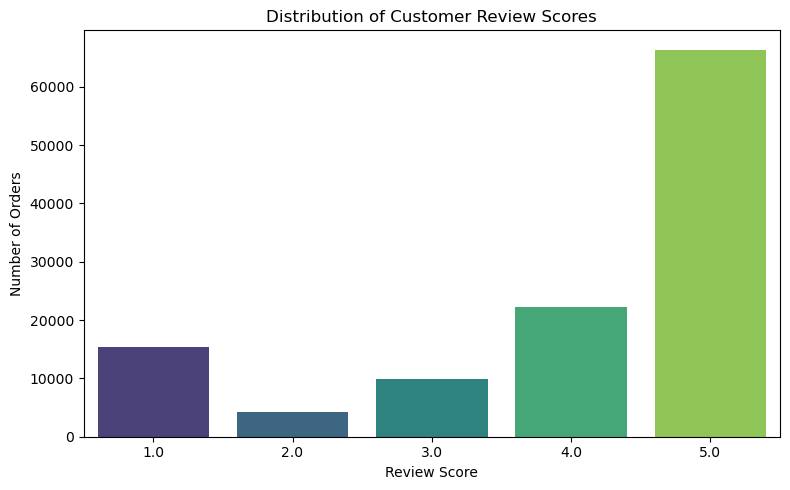

In [6]:
# Distribution of customer review scores
plt.figure(figsize=(8, 5))
sns.countplot(x="review_score", data=df, palette="viridis")
plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

### Review Score Distribution insight
The majority of customers gave a score of 5, making it the most common rating by a significant margin. Scores of 1 also appear frequently, suggesting a polarized customer experience. Scores of 2 and 3 are the least common. 
This distribution confirms a class imbalance that will need to be addressed during model building.

### Chart 2) PAymenrt Type Destribution

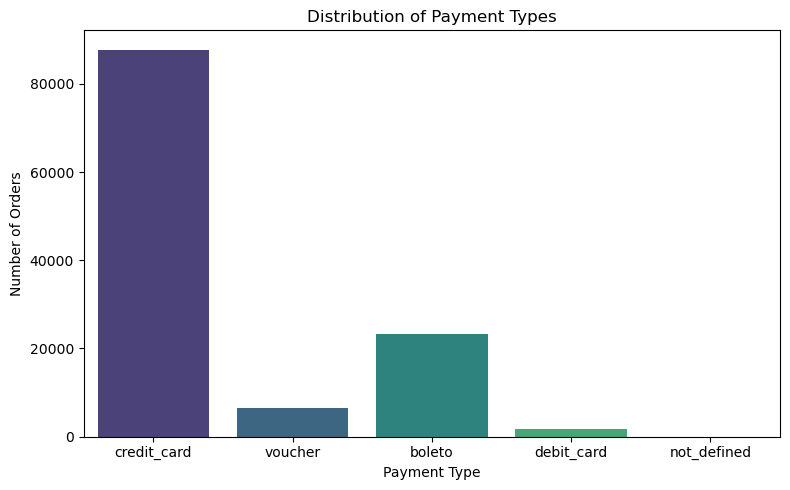

In [7]:
# Plot the distribution of payment types
plt.figure(figsize=(8, 5))
sns.countplot(x="payment_type", data=df, palette="viridis")
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

### Insight Payment Type Distribution 
Credit card is the dominant payment method, followed by boleto, a common Brazilian payment option. Voucher and debit card usage is minimal. This makes payment value and installments important features for our model.

### Chart 3) Compare Average Payment Value across review scores 

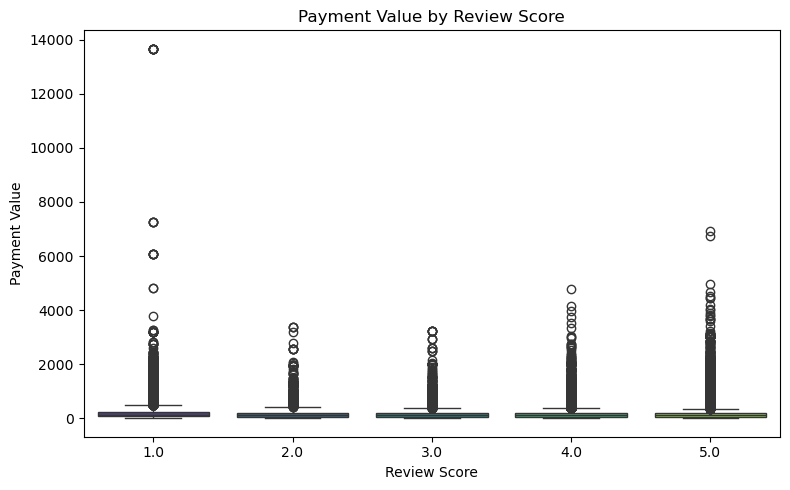

In [8]:
# Compare average payment value across review scores
plt.figure(figsize=(8, 5))
sns.boxplot(x="review_score", y="payment_value", data=df, palette="viridis")
plt.title("Payment Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Payment Value")
plt.tight_layout()
plt.show()

### Insight on Payment Value by Review Score 
Payment value is broadly similar across all review scores, suggesting that how much a customer spends does not strongly influence their satisfaction level. However score 1 shows the most extreme outliers with payments exceeding 13,000, indicating that high value orders that go wrong tend to generate the most negative reviews.

### Chart 4) Product Price by review 

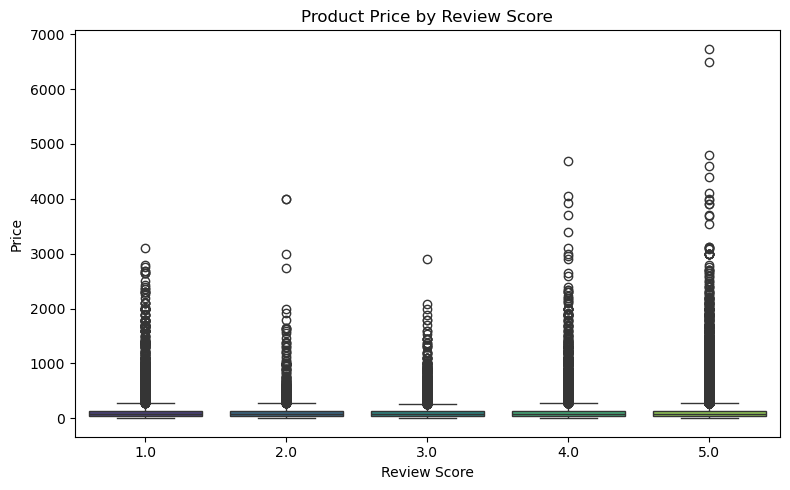

In [9]:
# Compare average price across review scores 
plt.figure(figsize=(8, 5))
sns.boxplot(x="review_score", y="price", data=df, palette="viridis")
plt.title("Product Price by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Insight on Product Price by Review Score 
Product price is relatively consistent across all review scores, indicating that price alone does not determine customer satisfaction. Higher priced outliers appear across all score levels with score 5 showing the widest price range, suggesting customers are willing to pay more and still leave positive reviews when their experience 
meets expectations.

### Chart 5) Correlation Heatmap of Numeric Features

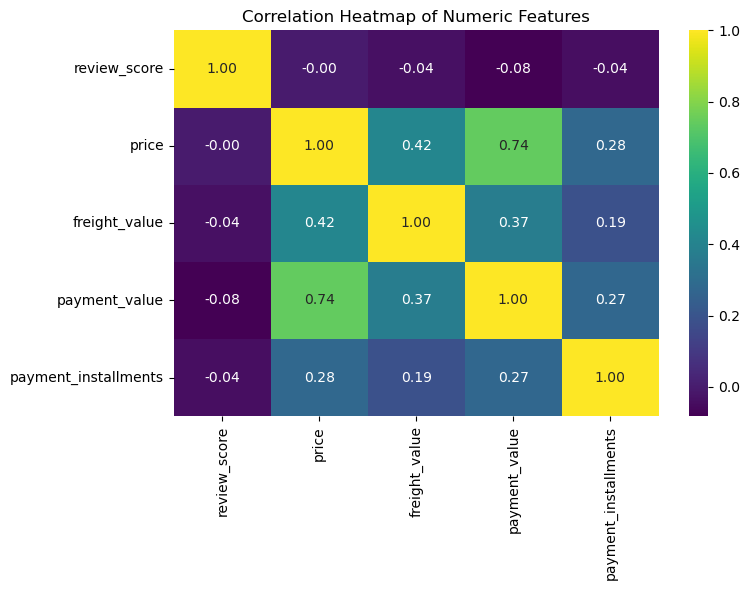

In [10]:
# Select numeric columns for correlation analysis
numeric_cols = df[["review_score", "price", "freight_value", 
                    "payment_value", "payment_installments"]]

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### Correlation Heatmap Explained
None of the numeric features show a strong correlation with review_score, confirming that customer satisfaction is not driven by price, freight, or payment value alone. However price and payment_value show a strong correlation of 0.74, which is expected since higher priced items naturally lead to higher payment amounts. This tells us that our model will need to rely on a combination of features rather than any single variable to predict customer satisfaction.